# Práctica Final NLP — Ejercicio 4: Reporte de métricas y conclusiones

**Bootcamp IA · Módulo de NLP**

Tomamos el modelo elegido en el Ejercicio 3 (la **regresión logística** sobre la bolsa de palabras)
y lo validamos en profundidad: calculamos las métricas que miden su bondad, las interpretamos y
cerramos con las conclusiones finales de toda la práctica.

## Contenido del notebook
1. Carga del modelo y de los datos
2. Reconstrucción del conjunto de test
3. Métricas de clasificación
4. Matriz de confusión
5. Curvas ROC y Precision-Recall
6. Palabras más influyentes
7. Conclusiones finales

## 0. Librerías

In [ ]:
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             PrecisionRecallDisplay, roc_auc_score,
                             average_precision_score, accuracy_score)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

## 1. Carga del modelo y de los datos

Cargamos el vectorizer y el modelo guardados en el Ejercicio 3, junto con el dataset preprocesado.

In [ ]:
vectorizer = joblib.load('data/vectorizer.joblib')
modelo = joblib.load('data/modelo_final.joblib')

df = pd.read_csv('data/reviews_preprocesado.csv')
df['texto_limpio'] = df['texto_limpio'].fillna('').astype(str)

print('Modelo cargado:', type(modelo).__name__)
print('Reviews:', len(df))

Modelo cargado: LogisticRegression
Reviews: 9482


## 2. Reconstrucción del conjunto de test

Reproducimos exactamente el mismo reparto train/test del Ejercicio 3 (mismo `random_state` y misma
estratificación), de modo que evaluamos sobre las reviews que el modelo no vio al entrenar.

In [ ]:
X = df['texto_limpio']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

X_test_vec = vectorizer.transform(X_test)
y_pred = modelo.predict(X_test_vec)

print('Reviews en test:', len(X_test))

Reviews en test: 1897


## 3. Métricas de clasificación

Por el desbalanceo del corpus, el **accuracy es engañoso** (predecir siempre "positivo" ya da
~95%). Las métricas relevantes son **precision, recall y F1**, sobre todo de la **clase negativa**,
y el **F1 macro**, que promedia ambas clases por igual.

In [ ]:
print('Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred,
                            target_names=['negativo', 'positivo'],
                            zero_division=0))

Accuracy: 0.953

              precision    recall  f1-score   support

    negativo       0.52      0.63      0.57        93
    positivo       0.98      0.97      0.98      1804

    accuracy                           0.95      1897
   macro avg       0.75      0.80      0.77      1897
weighted avg       0.96      0.95      0.96      1897



Lectura de las métricas:

- La clase **positiva** se clasifica muy bien (precision y recall altos): hay muchos ejemplos y el
  vocabulario positivo es claro.
- La clase **negativa** es la difícil: con pocas reviews para aprender, el modelo recupera buena
  parte de las negativas (recall razonable) pero con bastantes falsos positivos (precision más
  baja)

## 4. Matriz de confusión

La mostramos en valores absolutos y normalizada por fila (porcentaje de aciertos dentro de cada
clase real), que deja ver mejor el recall de la minoritaria.

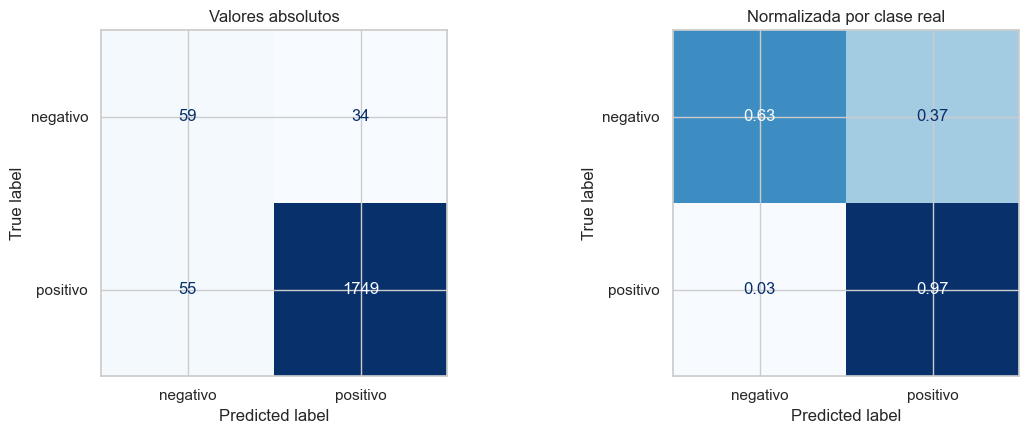

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['negativo', 'positivo']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Valores absolutos')

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['negativo', 'positivo']).plot(
    ax=axes[1], cmap='Blues', colorbar=False, values_format='.2f')
axes[1].set_title('Normalizada por clase real')

plt.tight_layout()
plt.show()

## 5. Curvas ROC y Precision-Recall

Estas curvas valoran el modelo a lo largo de todos los umbrales de decisión. Usamos la puntuación
continua del modelo (`predict_proba` o `decision_function`)

ROC AUC: 0.933
Average Precision (clase positiva): 0.996


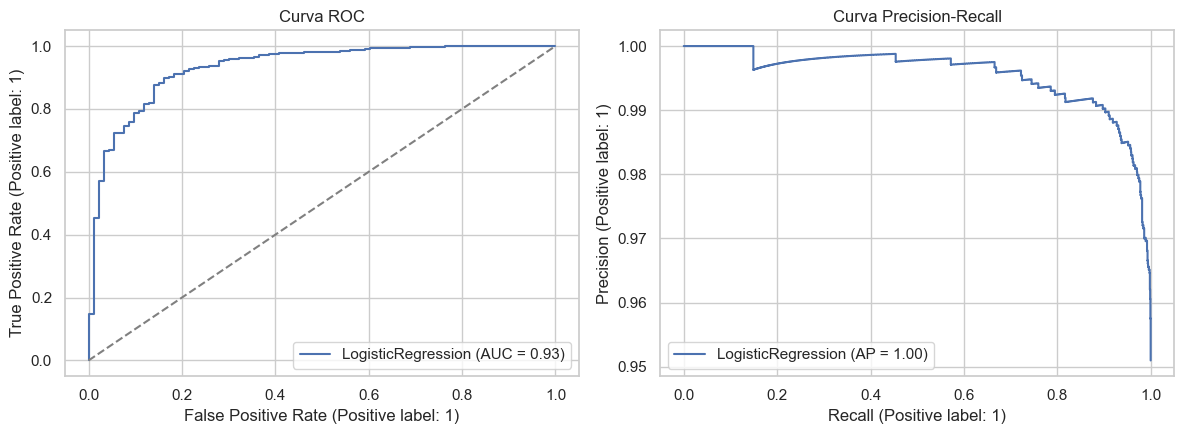

In [ ]:
# Puntuacion continua de la clase positiva
if hasattr(modelo, 'predict_proba'):
    y_score = modelo.predict_proba(X_test_vec)[:, 1]
else:
    y_score = modelo.decision_function(X_test_vec)

print('ROC AUC:', round(roc_auc_score(y_test, y_score), 3))
print('Average Precision (clase positiva):', round(average_precision_score(y_test, y_score), 3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[0], name=type(modelo).__name__)
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('Curva ROC')
PrecisionRecallDisplay.from_predictions(y_test, y_score, ax=axes[1], name=type(modelo).__name__)
axes[1].set_title('Curva Precision-Recall')
plt.tight_layout()
plt.show()

## 6. Palabras más influyentes

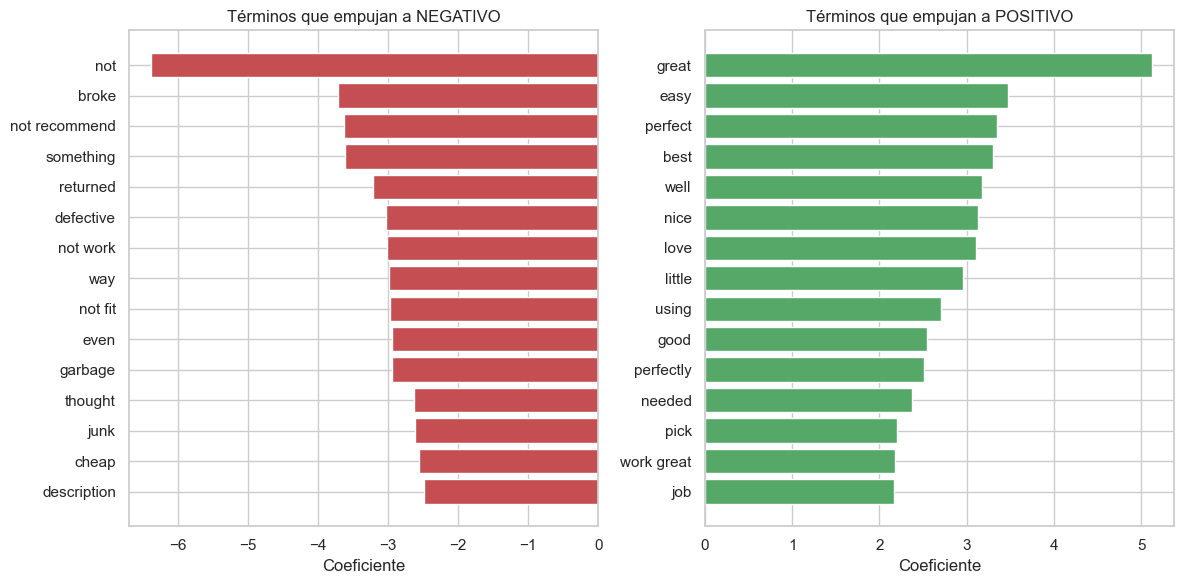

In [ ]:
features = np.array(vectorizer.get_feature_names_out())
coef = modelo.coef_[0]

orden = np.argsort(coef)
top_neg = orden[:15]
top_pos = orden[-15:]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].barh(features[top_neg][::-1], coef[top_neg][::-1], color='#C44E52')
axes[0].set_title('Términos que empujan a NEGATIVO')
axes[0].set_xlabel('Coeficiente')
axes[1].barh(features[top_pos], coef[top_pos], color='#55A868')
axes[1].set_title('Términos que empujan a POSITIVO')
axes[1].set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

Términos como `great`, `perfect`, `love` o `best` empujan a positivo, mientras que `defective`, `garbage`, `junk`, `broke` o `returned` empujan a negativo

## 7. Conclusiones finales

**Sobre el pipeline**
- Hemos recorrido un proyecto de análisis de sentimiento completo: descarga y EDA, preprocesado,
  entrenamiento comparando dos modelos y validación del elegido.
- El modelo final es una **regresión logística** sobre una **bolsa de palabras con TF-IDF**
  (unigramas y bigramas), entrenada con `class_weight='balanced'` para tratar el desbalanceo.

**Sobre los resultados**
- El **accuracy (~95%) es engañoso** por el desbalanceo, así que la valoración se apoya en el **F1 macro** y en las métricas de la **clase negativa**.
- El modelo clasifica bien las reviews positivas y detecta una parte razonable de las negativas, que son escasas. El **ROC AUC alto** confirma que ordena bien los ejemplos.
- Los **coeficientes** del modelo son coherentes con el lenguaje de las reviews, lo que da confianza en lo aprendido.

**Limitaciones y posibles mejoras**
- La principal limitación es la **escasez de reviews negativas**. Con más ejemplos negativos
- Podrían probarse **embeddings o modelos basados en transformers**, o **ajustar el umbral** dedecisión según interese más precision o recall en negativo.